<div align="center">

<br><br>

### *TP: DESAFÍO ESPECIAL - FINAL*

<br>

<img src="img/logo_itba.png" width="450">

<br><br><br>

**Curso:** Ventilación Mecánica - 16.09

<br><br>

**Autor:**
Thiago Massone - 60035

<br><br>

**Fecha:** 13/07/2026

</div>

<div style="page-break-after: always;"></div>

## Motivación

El seguimiento de la mecánica respiratoria de un paciente —cómo evolucionan su
resistencia (R) y su compliance (C) entre controles sucesivos— permite detectar
deterioro o mejoría pulmonar a lo largo del tiempo. Para que esa comparación sea
válida, R y C deben estimarse siempre bajo la misma condición: **respiraciones
pasivas** (Pmus ≈ 0), donde toda la presión que mueve el aire proviene del
respirador. Si el paciente hace esfuerzo, la mecánica estimada se distorsiona y
la tendencia deja de ser confiable.

## Punto de partida y mejora propuesta

En la entrega de la cursada (Consigna 4), los tramos pasivos se seleccionaron con
un criterio basado en el desvío estándar de la presión esofágica (Pes) en ventanas
de 4s. Ese criterio dejó pasar una respiración con esfuerzo del paciente (Ciclo 1),
según se señaló en la corrección del informe: el desvío estándar promedia la ventana
y no distingue la caída brusca de Pes que delata el esfuerzo inspiratorio.

Este trabajo automatiza la detección de respiraciones pasivas sobre todo el registro,
con un criterio basado en la forma de la curva de Pes y confirmado por la consistencia
de los parámetros estimados, para estimar R y C sin selección manual.

In [3]:
%pip install pandas numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)

# Parámetros de adquisición del sistema FluxMed
cols = ['Time', 'Flow', 'Volume', 'Paw', 'Pes', 'Ptpulm', 'Pga', 'Ptdiaf', 'CO2']
fs = 256          # Hz
dt = 1 / fs       # s

In [6]:
# La señal D fue seleccionada en la entrega anterior (Consigna 4) por presentar la
# menor variabilidad de Pes y la mayor cantidad de muestras. Aquí se parte de esa
# elección y se trabaja directamente sobre ella.
df = pd.read_csv('signals/Mini_TP_Signals_D.txt', sep='\t', skiprows=6, names=cols,
                 usecols=range(9), encoding='latin-1')

dur = df.Time.iloc[-1] - df.Time.iloc[0]
print(f"Señal D: {len(df)} muestras, duración {dur:.0f} s, fs = {fs} Hz")

Señal D: 431596 muestras, duración 1686 s, fs = 256 Hz


## 1. Verificación de la corrección: ¿es detectable el esfuerzo del Ciclo 1?

Antes de automatizar la detección, se verifica cuantitativamente la observación: el Ciclo 1 (t = 2092–2096 s), seleccionado como pasivo en la entrega anterior,
en realidad contiene esfuerzo del paciente.

La firma física del esfuerzo es una **caída brusca de Pes al inicio de la inspiración**:
cuando el diafragma se activa, la presión pleural (subrogada por Pes) cae, en lugar de
acompañar suavemente la subida de Paw como ocurre en una respiración pasiva. Se compara
el Ciclo 1 contra los Ciclos 2, 3 y 4 (seleccionados como pasivos y consistentes entre sí)
para confirmar que esa caída distingue al Ciclo 1 del resto.

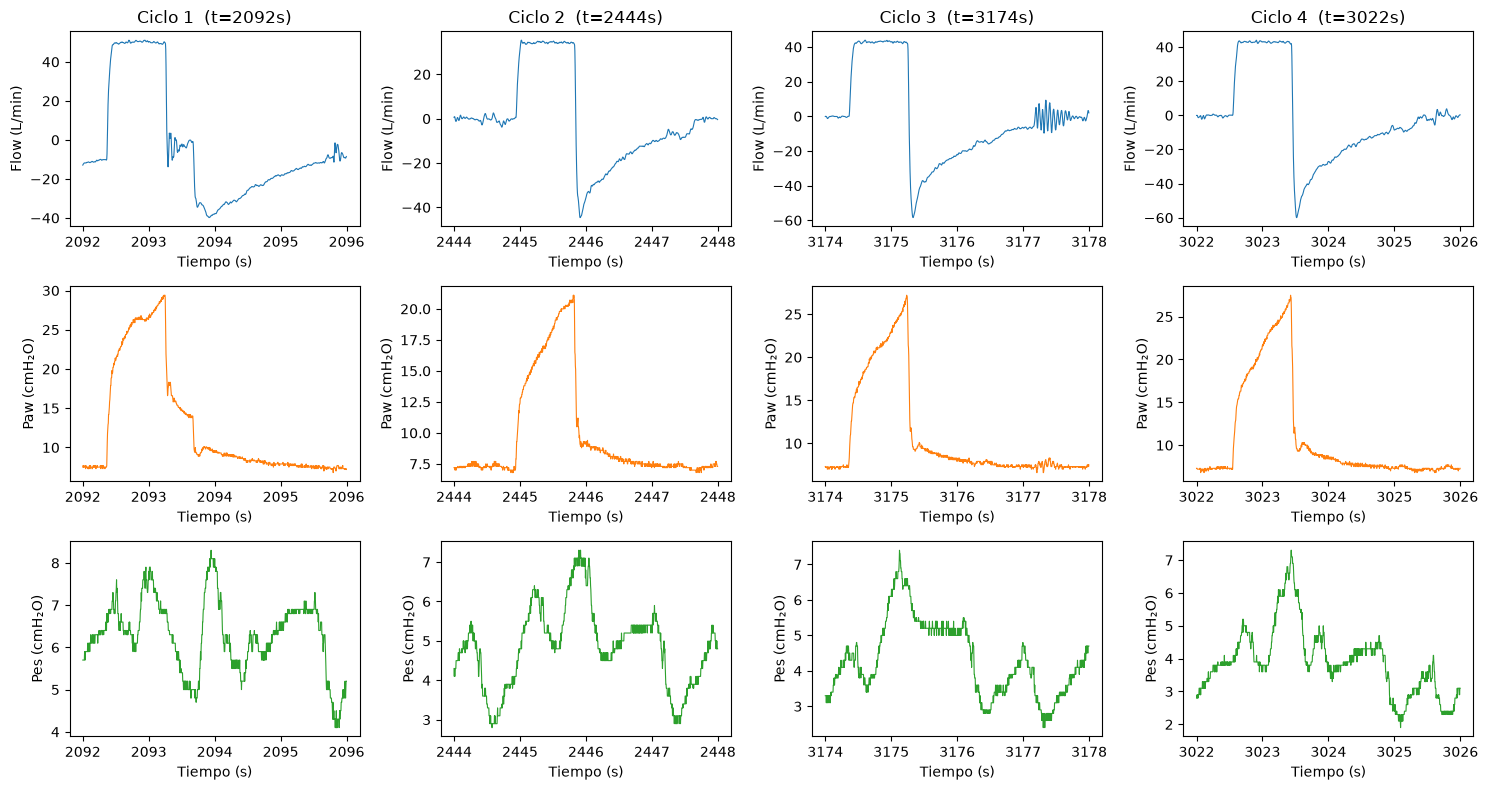

In [8]:
# Ventanas de los 4 ciclos seleccionados en la entrega anterior
ciclos_t = {1: 2092.0, 2: 2444.0, 3: 3174.0, 4: 3022.0}

fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for j, (nc, t0) in enumerate(ciclos_t.items()):
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)]

    axes[0, j].plot(sub.Time, sub.Flow, lw=0.8)
    axes[0, j].set_title(f'Ciclo {nc}  (t={t0:.0f}s)')
    axes[0, j].set_xlabel('Tiempo (s)')
    axes[0, j].set_ylabel('Flow (L/min)')

    axes[1, j].plot(sub.Time, sub.Paw, lw=0.8, color='tab:orange')
    axes[1, j].set_xlabel('Tiempo (s)')
    axes[1, j].set_ylabel('Paw (cmH₂O)')

    axes[2, j].plot(sub.Time, sub.Pes, lw=0.8, color='tab:green')
    axes[2, j].set_xlabel('Tiempo (s)')
    axes[2, j].set_ylabel('Pes (cmH₂O)')

plt.tight_layout()
plt.show()

### 1.1 Diagnóstico cuantitativo de los 4 ciclos

Para elegir con criterio la métrica que usará el detector automático, se cuantifican
tres indicadores sobre cada uno de los 4 ciclos, cada uno sensible a una manifestación
distinta del esfuerzo del paciente:

- **Correlación Pes–Paw durante la inspiración:** en una respiración pasiva Pes acompaña
  a Paw (ambas crecen por el retroceso elástico), dando correlación alta y positiva. El
  esfuerzo del paciente degrada esa relación.
- **Caída de Paw dentro de la inspiración:** mide cuánto retrocede Paw desde su pico antes
  de terminar la fase inspiratoria. La caída de la presión de plateau en plena inspiración
  es la firma señalada por el docente en el Ciclo 1.
- **Calidad de ajuste (R²) del modelo de 2 elementos por ciclo:** una respiración pasiva se
  ajusta bien al modelo Paw = R·F + E·V + PEEP; el esfuerzo lo rompe y reduce el R².

El objetivo es identificar cuál de estos indicadores separa de forma más clara al Ciclo 1
de los Ciclos 2, 3 y 4.

In [9]:
def diagnostico_ciclo(t0, df, fs, dur=4.0):
    """Calcula 3 indicadores de pasividad sobre una ventana de ciclo.
    Detección de inspiración por Flow>0; volumen integrado dentro de la ventana.
    Es diagnóstico sobre ciclos conocidos, no el pipeline automático final."""
    sub = df[(df.Time >= t0) & (df.Time < t0 + dur)].copy()

    F = sub.Flow.values / 60.0            # L/min -> L/s
    Paw = sub.Paw.values
    Pes = sub.Pes.values

    # Volumen integrado dentro de la ventana (reset a 0 al inicio)
    V = np.cumsum(F) / fs                 # L
    V = V - V[0]

    # Fase inspiratoria: flujo positivo
    insp = F > 0

    # (1) Correlación Pes-Paw durante la inspiración
    corr = np.corrcoef(Paw[insp], Pes[insp])[0, 1]

    # (2) Caída de Paw dentro de la inspiración: pico - valor al final de la inspiración
    paw_insp = Paw[insp]
    caida_paw = paw_insp.max() - paw_insp[-1]

    # (3) R² del ajuste de 2 elementos sobre todo el ciclo
    X = np.column_stack([F, V, np.ones_like(F)])
    beta, _, _, _ = np.linalg.lstsq(X, Paw, rcond=None)
    Paw_pred = X @ beta
    r2 = 1 - np.sum((Paw - Paw_pred)**2) / np.sum((Paw - Paw.mean())**2)

    return corr, caida_paw, r2


print(f"{'Ciclo':>6} {'corr(Pes,Paw)':>15} {'caída Paw (cmH₂O)':>20} {'R²':>8}")
for nc, t0 in ciclos_t.items():
    corr, caida, r2 = diagnostico_ciclo(t0, df, fs)
    print(f"{nc:>6} {corr:>15.3f} {caida:>20.2f} {r2:>8.3f}")

 Ciclo   corr(Pes,Paw)    caída Paw (cmH₂O)       R²
     1           0.247                13.60    0.970
     2           0.648                13.80    0.988
     3           0.792                19.70    0.990
     4           0.755                20.20    0.991


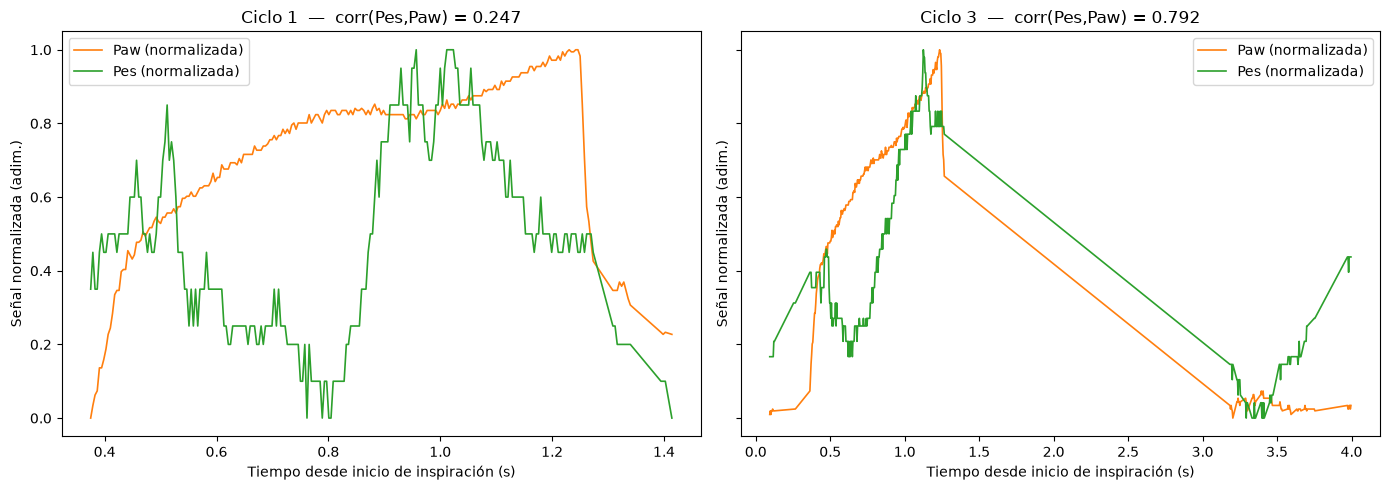

In [10]:
def normalizar(x):
    """Lleva una señal al rango [0,1] para comparar formas independientemente de la escala."""
    return (x - x.min()) / (x.max() - x.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (nc, t0) in zip(axes, [(1, 2092.0), (3, 3174.0)]):
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].copy()
    F = sub.Flow.values / 60.0
    insp = F > 0

    # tiempo relativo al inicio de la ventana, solo fase inspiratoria
    t_rel = sub.Time.values[insp] - t0
    paw_n = normalizar(sub.Paw.values[insp])
    pes_n = normalizar(sub.Pes.values[insp])

    # correlación para anotarla en el título
    r = np.corrcoef(sub.Paw.values[insp], sub.Pes.values[insp])[0, 1]

    ax.plot(t_rel, paw_n, color='tab:orange', lw=1.2, label='Paw (normalizada)')
    ax.plot(t_rel, pes_n, color='tab:green', lw=1.2, label='Pes (normalizada)')
    ax.set_title(f'Ciclo {nc}  —  corr(Pes,Paw) = {r:.3f}')
    ax.set_xlabel('Tiempo desde inicio de inspiración (s)')
    ax.set_ylabel('Señal normalizada (adim.)')
    ax.legend()

plt.tight_layout()
plt.show()

### 1.2 Delimitación de la fase inspiratoria por cruces de flujo

El diagnóstico anterior usó `Flow > 0` para aislar la inspiración, criterio demasiado
grueso: en algunos ciclos incorpora parte de la espiración, contaminando la medición.
Para que la correlación Pes–Paw sea comparable entre ciclos, se delimita la fase
inspiratoria de forma consistente: la inspiración comienza cuando el flujo cruza de
negativo a positivo (con un umbral que evita disparos por ruido) y termina cuando el
flujo vuelve a cruzar a cero. La correlación se mide únicamente en ese tramo.

In [11]:
def fase_inspiratoria(sub, umbral=2.0):
    """Devuelve los índices (inicio, fin) de la primera inspiración dentro de la ventana.
    Inicio: flujo cruza de <umbral a >=umbral (arranque real de inspiración).
    Fin: flujo vuelve a cruzar a <=0 después del inicio.
    umbral en L/min, con margen para no disparar por ruido alrededor de cero."""
    F = sub.Flow.values

    # Índices donde el flujo está por encima del umbral (inspiración activa)
    inspirando = F >= umbral

    if not inspirando.any():
        return None, None

    # Inicio: primer índice donde arranca la inspiración
    i_ini = np.argmax(inspirando)  # primer True

    # Fin: primer índice después del inicio donde el flujo vuelve a <= 0
    resto = F[i_ini:]
    cruce_baja = np.where(resto <= 0)[0]
    i_fin = i_ini + cruce_baja[0] if len(cruce_baja) else len(F) - 1

    return i_ini, i_fin


print(f"{'Ciclo':>6} {'t inicio insp':>14} {'dur insp (s)':>14} {'corr(Pes,Paw)':>15}")
for nc, t0 in ciclos_t.items():
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub)

    Paw_insp = sub.Paw.values[i_ini:i_fin]
    Pes_insp = sub.Pes.values[i_ini:i_fin]
    r = np.corrcoef(Paw_insp, Pes_insp)[0, 1]

    t_ini = sub.Time.values[i_ini]
    dur_insp = (i_fin - i_ini) / fs
    print(f"{nc:>6} {t_ini:>14.2f} {dur_insp:>14.2f} {r:>15.3f}")

 Ciclo  t inicio insp   dur insp (s)   corr(Pes,Paw)
     1        2092.38           0.90           0.139
     2        2444.47           0.03          -0.201
     3        3174.37           0.90           0.739
     4        3022.56           0.90           0.556


In [ ]:
def fase_inspiratoria(sub, umbral=2.0, dur_min=0.3, fs=256):
    """Devuelve los índices (inicio, fin) de la inspiración real dentro de la ventana.
    Busca el tramo de flujo positivo sostenido MÁS LARGO (no el primero), para no
    confundir pinchazos de ruido con la inspiración.
    umbral en L/min; dur_min en segundos (descarta tramos demasiado cortos)."""
    F = sub.Flow.values
    inspirando = F >= umbral

    if not inspirando.any():
        return None, None

    # Detectar bordes de los tramos contiguos de inspiración
    # diff sobre el array booleano: +1 donde arranca un tramo, -1 donde termina
    bordes = np.diff(inspirando.astype(int))
    inicios = np.where(bordes == 1)[0] + 1
    finales = np.where(bordes == -1)[0] + 1

    # Contemplar que la ventana arranque o termine en pleno tramo
    if inspirando[0]:
        inicios = np.insert(inicios, 0, 0)
    if inspirando[-1]:
        finales = np.append(finales, len(F))

    if len(inicios) == 0:
        return None, None

    # Quedarse con el tramo más largo
    duraciones = finales - inicios
    k = np.argmax(duraciones)
    i_ini, i_fin = inicios[k], finales[k]

    # Descartar si ni el tramo más largo alcanza la duración mínima física
    if (i_fin - i_ini) / fs < dur_min:
        return None, None

    return i_ini, i_fin


print(f"{'Ciclo':>6} {'t inicio insp':>14} {'dur insp (s)':>14} {'corr(Pes,Paw)':>15}")
for nc, t0 in ciclos_t.items():
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)

    if i_ini is None:
        print(f"{nc:>6} {'sin inspiración válida':>44}")
        continue

    Paw_insp = sub.Paw.values[i_ini:i_fin]
    Pes_insp = sub.Pes.values[i_ini:i_fin]
    r = np.corrcoef(Paw_insp, Pes_insp)[0, 1]

    t_ini = sub.Time.values[i_ini]
    dur_insp = (i_fin - i_ini) / fs
    print(f"{nc:>6} {t_ini:>14.2f} {dur_insp:>14.2f} {r:>15.3f}")

In [12]:
def fase_inspiratoria(sub, umbral=2.0, persist_s=0.1, fs=256):
    """Delimita la inspiración por cruces de flujo SOSTENIDOS (histéresis).
    Inicio: flujo supera +umbral y se mantiene arriba al menos persist_s.
    Fin: después del inicio, flujo cae por debajo de -umbral y se mantiene
         abajo al menos persist_s (arranque real de espiración).
    La pausa inspiratoria (flujo ≈ 0) queda incluida, porque no es negativo sostenido."""
    F = sub.Flow.values
    n = len(F)
    persist = int(persist_s * fs)  # muestras que debe durar para considerarse sostenido

    def primer_tramo_sostenido(condicion, desde=0):
        """Primer índice a partir de 'desde' donde 'condicion' se cumple por >= persist muestras seguidas."""
        cond = condicion.astype(int)
        i = desde
        while i <= n - persist:
            if cond[i:i+persist].all():
                return i
            i += 1
        return None

    # Inicio: primer tramo de flujo POSITIVO sostenido (por encima de +umbral)
    i_ini = primer_tramo_sostenido(F >= umbral, desde=0)
    if i_ini is None:
        return None, None

    # Fin: primer tramo de flujo NEGATIVO sostenido (por debajo de -umbral) después del inicio
    i_fin = primer_tramo_sostenido(F <= -umbral, desde=i_ini + persist)
    if i_fin is None:
        i_fin = n  # si no hay espiración clara dentro de la ventana, cortar al final

    return i_ini, i_fin


print(f"{'Ciclo':>6} {'t inicio insp':>14} {'dur insp (s)':>14} {'corr(Pes,Paw)':>15}")
for nc, t0 in ciclos_t.items():
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)

    if i_ini is None:
        print(f"{nc:>6} {'sin inspiración válida':>44}")
        continue

    Paw_insp = sub.Paw.values[i_ini:i_fin]
    Pes_insp = sub.Pes.values[i_ini:i_fin]
    r = np.corrcoef(Paw_insp, Pes_insp)[0, 1]

    t_ini = sub.Time.values[i_ini]
    dur_insp = (i_fin - i_ini) / fs
    print(f"{nc:>6} {t_ini:>14.2f} {dur_insp:>14.2f} {r:>15.3f}")

 Ciclo  t inicio insp   dur insp (s)   corr(Pes,Paw)
     1        2092.38           1.05           0.376
     2        2444.95           0.90           0.339
     3        3174.37           0.90           0.739
     4        3022.56           0.90           0.556


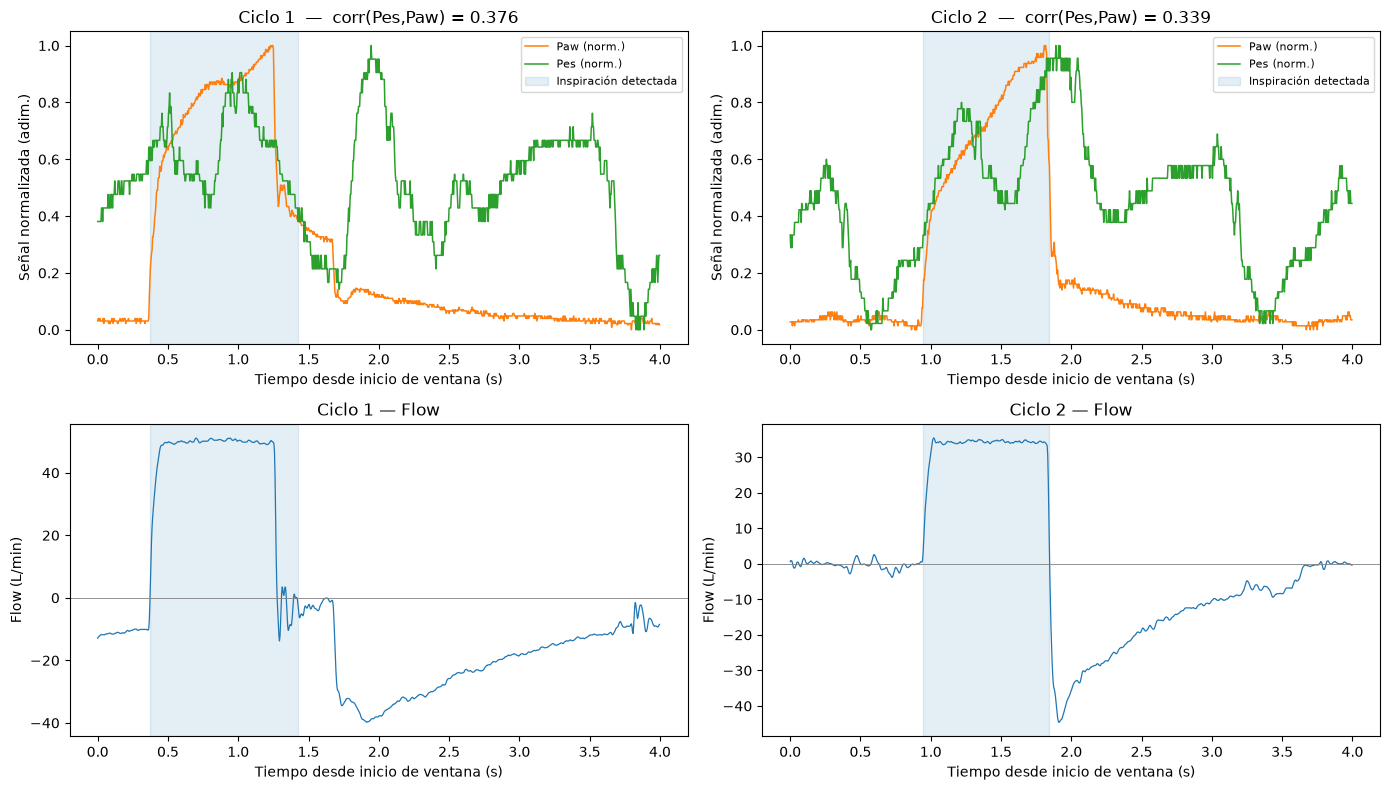

In [13]:
def normalizar(x):
    return (x - x.min()) / (x.max() - x.min())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for j, (nc, t0) in enumerate([(1, 2092.0), (2, 2444.0)]):
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)

    t = sub.Time.values - t0                      # tiempo relativo
    t_ini, t_fin = t[i_ini], t[i_fin - 1]         # límites de la inspiración detectada

    # correlación sobre el tramo detectado (lo que mide el detector)
    r = np.corrcoef(sub.Paw.values[i_ini:i_fin], sub.Pes.values[i_ini:i_fin])[0, 1]

    # --- fila de arriba: Paw y Pes normalizadas (ventana completa) ---
    axes[0, j].plot(t, normalizar(sub.Paw.values), color='tab:orange', lw=1.1, label='Paw (norm.)')
    axes[0, j].plot(t, normalizar(sub.Pes.values), color='tab:green',  lw=1.1, label='Pes (norm.)')
    axes[0, j].axvspan(t_ini, t_fin, color='tab:blue', alpha=0.12, label='Inspiración detectada')
    axes[0, j].set_title(f'Ciclo {nc}  —  corr(Pes,Paw) = {r:.3f}')
    axes[0, j].set_xlabel('Tiempo desde inicio de ventana (s)')
    axes[0, j].set_ylabel('Señal normalizada (adim.)')
    axes[0, j].legend(fontsize=8)

    # --- fila de abajo: Flow, para ver la pausa y los límites ---
    axes[1, j].plot(t, sub.Flow.values, color='tab:blue', lw=0.9)
    axes[1, j].axhline(0, color='gray', lw=0.6)
    axes[1, j].axvspan(t_ini, t_fin, color='tab:blue', alpha=0.12)
    axes[1, j].set_title(f'Ciclo {nc} — Flow')
    axes[1, j].set_xlabel('Tiempo desde inicio de ventana (s)')
    axes[1, j].set_ylabel('Flow (L/min)')

plt.tight_layout()
plt.show()

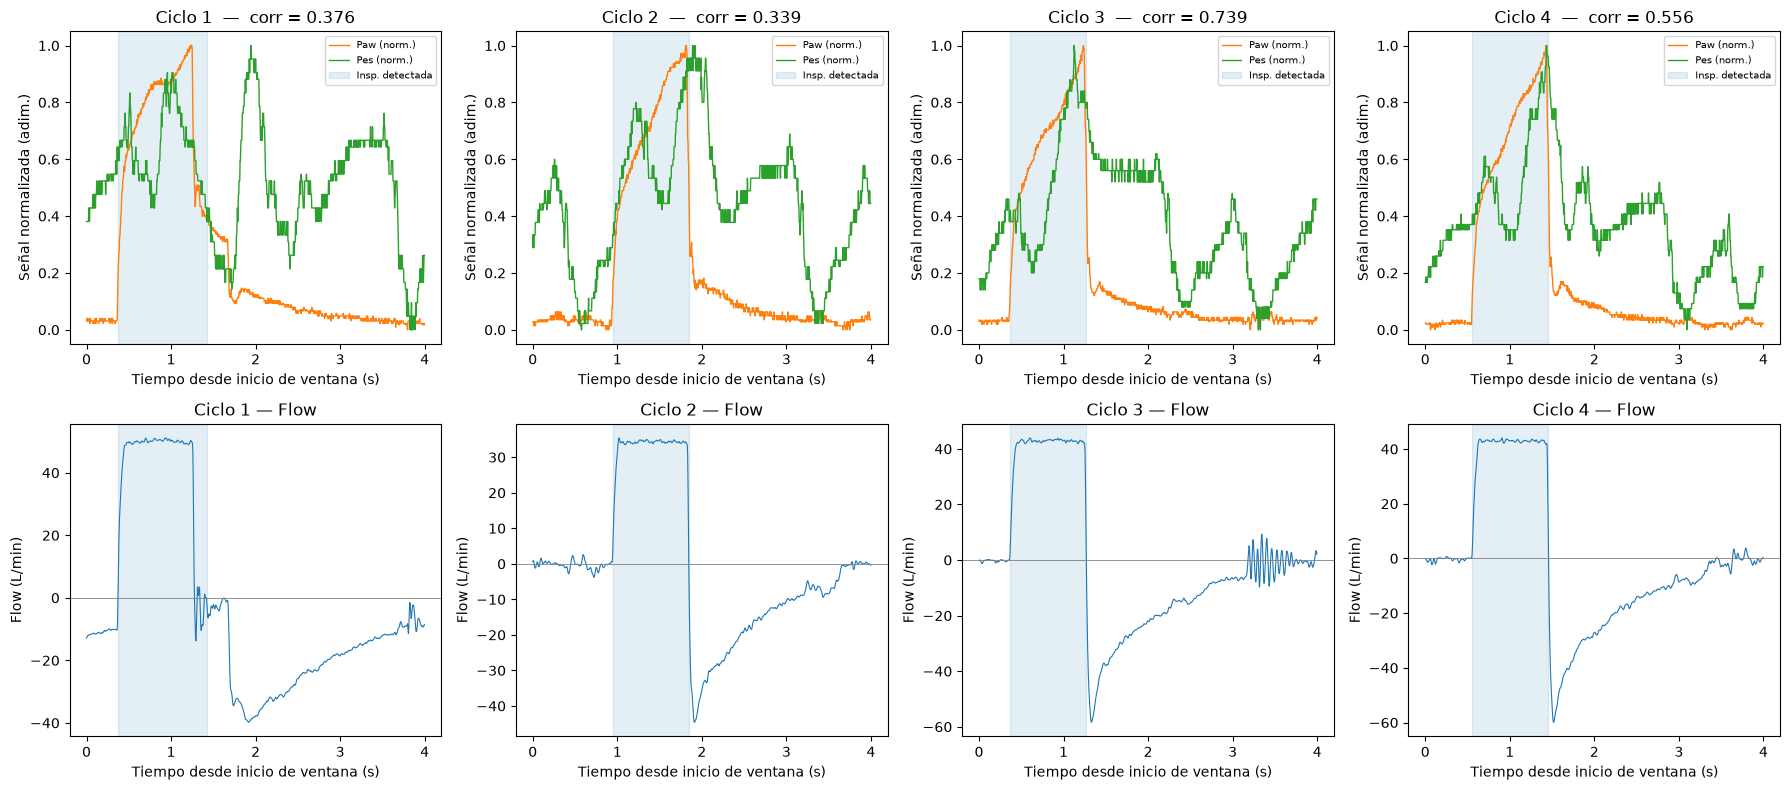

In [14]:
def normalizar(x):
    return (x - x.min()) / (x.max() - x.min())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for j, (nc, t0) in enumerate(ciclos_t.items()):
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)

    t = sub.Time.values - t0
    t_ini, t_fin = t[i_ini], t[i_fin - 1]
    r = np.corrcoef(sub.Paw.values[i_ini:i_fin], sub.Pes.values[i_ini:i_fin])[0, 1]

    # fila 0: Paw y Pes normalizadas
    axes[0, j].plot(t, normalizar(sub.Paw.values), color='tab:orange', lw=1.0, label='Paw (norm.)')
    axes[0, j].plot(t, normalizar(sub.Pes.values), color='tab:green',  lw=1.0, label='Pes (norm.)')
    axes[0, j].axvspan(t_ini, t_fin, color='tab:blue', alpha=0.12, label='Insp. detectada')
    axes[0, j].set_title(f'Ciclo {nc}  —  corr = {r:.3f}')
    axes[0, j].set_xlabel('Tiempo desde inicio de ventana (s)')
    axes[0, j].set_ylabel('Señal normalizada (adim.)')
    axes[0, j].legend(fontsize=7)

    # fila 1: Flow
    axes[1, j].plot(t, sub.Flow.values, color='tab:blue', lw=0.8)
    axes[1, j].axhline(0, color='gray', lw=0.6)
    axes[1, j].axvspan(t_ini, t_fin, color='tab:blue', alpha=0.12)
    axes[1, j].set_title(f'Ciclo {nc} — Flow')
    axes[1, j].set_xlabel('Tiempo desde inicio de ventana (s)')
    axes[1, j].set_ylabel('Flow (L/min)')

plt.tight_layout()
plt.show()

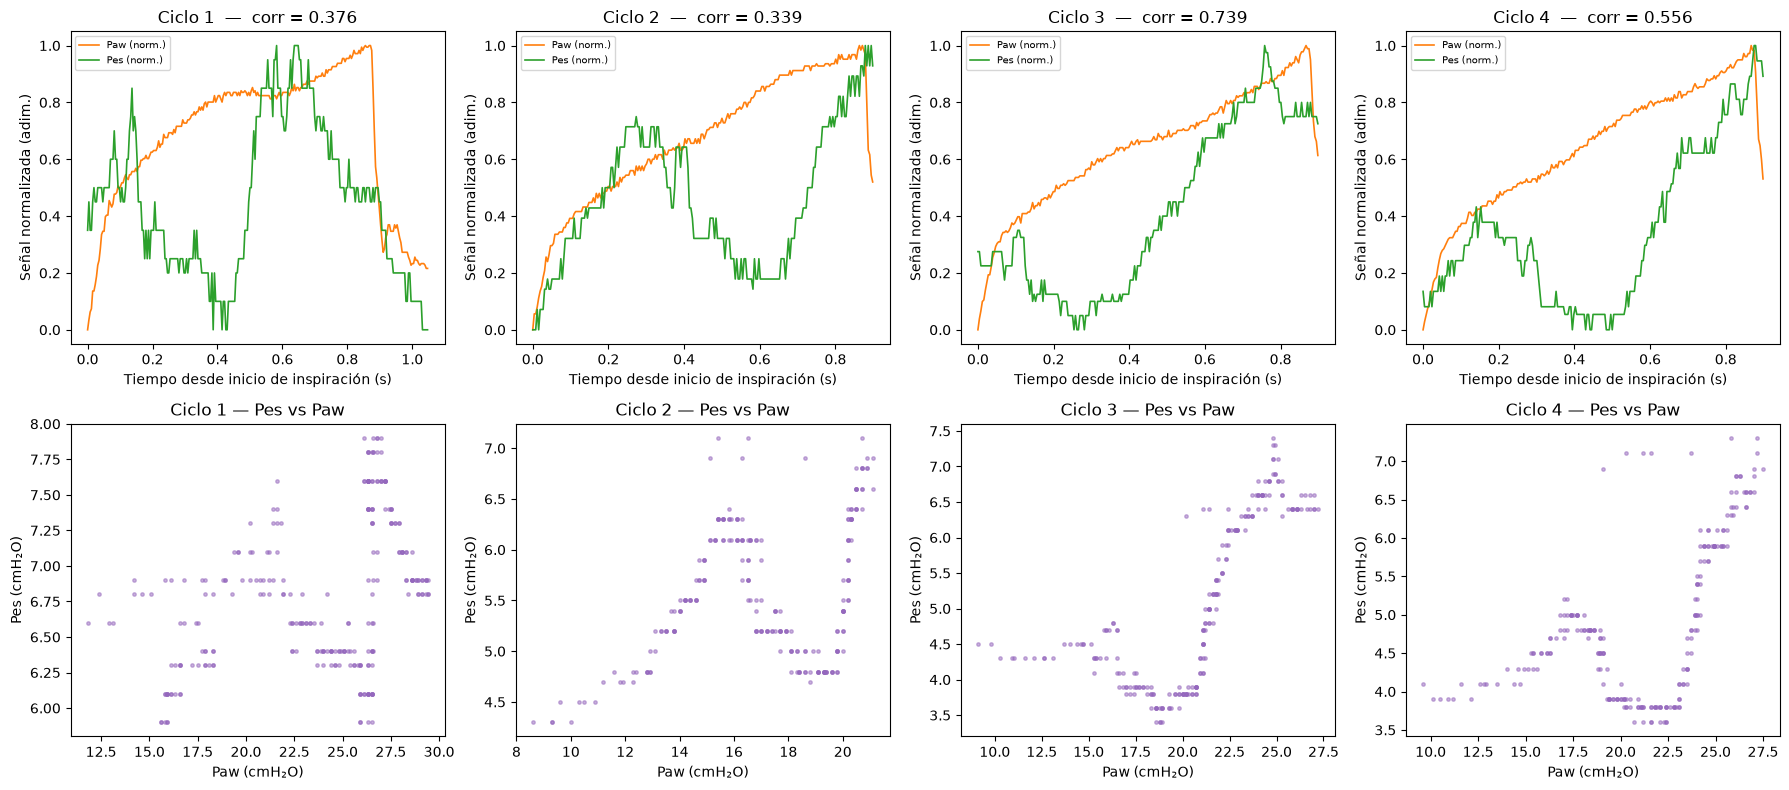

In [15]:
def normalizar(x):
    return (x - x.min()) / (x.max() - x.min())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for j, (nc, t0) in enumerate(ciclos_t.items()):
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)

    # recortar SOLO al tramo inspiratorio
    Paw_i = sub.Paw.values[i_ini:i_fin]
    Pes_i = sub.Pes.values[i_ini:i_fin]
    t_i   = (sub.Time.values[i_ini:i_fin] - sub.Time.values[i_ini])  # tiempo desde inicio insp

    r = np.corrcoef(Paw_i, Pes_i)[0, 1]

    # fila 0: Paw y Pes normalizadas DENTRO de la inspiración, vs tiempo
    axes[0, j].plot(t_i, normalizar(Paw_i), color='tab:orange', lw=1.2, label='Paw (norm.)')
    axes[0, j].plot(t_i, normalizar(Pes_i), color='tab:green',  lw=1.2, label='Pes (norm.)')
    axes[0, j].set_title(f'Ciclo {nc}  —  corr = {r:.3f}')
    axes[0, j].set_xlabel('Tiempo desde inicio de inspiración (s)')
    axes[0, j].set_ylabel('Señal normalizada (adim.)')
    axes[0, j].legend(fontsize=7)

    # fila 1: scatter Pes vs Paw (crudos, en la inspiración)
    axes[1, j].scatter(Paw_i, Pes_i, s=6, color='tab:purple', alpha=0.5)
    axes[1, j].set_title(f'Ciclo {nc} — Pes vs Paw')
    axes[1, j].set_xlabel('Paw (cmH₂O)')
    axes[1, j].set_ylabel('Pes (cmH₂O)')

plt.tight_layout()
plt.show()

In [16]:
def metricas_ciclo(t0, df, fs):
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)
    if i_ini is None:
        return None

    F   = sub.Flow.values[i_ini:i_fin] / 60.0   # L/s
    Paw = sub.Paw.values[i_ini:i_fin]
    Pes = sub.Pes.values[i_ini:i_fin]

    # Volumen integrado dentro de la inspiración (reset a 0 al inicio)
    V = np.cumsum(F) / fs
    V = V - V[0]

    def r2_fit(y, cols):
        """Ajusta y ~ [cols, 1] por mínimos cuadrados; devuelve R² y desvío del residuo."""
        X = np.column_stack(cols + [np.ones_like(y)])
        beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        y_pred = X @ beta
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        resid_std = np.sqrt(ss_res / len(y))
        return r2, resid_std

    corr = np.corrcoef(Paw, Pes)[0, 1]                 # (ref) Pearson que veníamos usando
    r2_model, _ = r2_fit(Paw, [F, V])                  # (1) modelo de vía aérea
    r2_pes, resid_pes = r2_fit(Pes, [V, F])            # (2) modelo pasivo de Pes

    return corr, r2_model, r2_pes, resid_pes


print(f"{'Ciclo':>6} {'corr(Pes,Paw)':>14} {'R² Paw':>9} {'R² Pes~V,F':>12} {'resid Pes (cmH₂O)':>18}")
for nc, t0 in ciclos_t.items():
    m = metricas_ciclo(t0, df, fs)
    if m is None:
        print(f"{nc:>6} {'sin inspiración válida':>40}")
        continue
    corr, r2_model, r2_pes, resid_pes = m
    print(f"{nc:>6} {corr:>14.3f} {r2_model:>9.3f} {r2_pes:>12.3f} {resid_pes:>18.3f}")

 Ciclo  corr(Pes,Paw)    R² Paw   R² Pes~V,F  resid Pes (cmH₂O)
     1          0.376     0.945        0.232              0.459
     2          0.339     0.966        0.174              0.608
     3          0.739     0.981        0.762              0.567
     4          0.556     0.983        0.472              0.729


In [28]:
def fase_inspiratoria(sub, umbral_in=2.0, umbral_out=0.5, persist_s=0.1, confirm_s=0.12, fs=256):
    """Inicio: flujo supera +umbral_in sostenido por persist_s.
    Fin: flujo cae por debajo de +umbral_out y NO vuelve a superarlo dentro de confirm_s.
    Usar umbral_out bajo y ventana de confirmación más larga evita que las oscilaciones
    de transición (que rebotan alrededor de cero) extiendan o adelanten el corte."""
    F = sub.Flow.values
    n = len(F)
    persist = int(persist_s * fs)
    confirm = max(1, int(confirm_s * fs))

    # Inicio
    c = (F >= umbral_in).astype(int)
    i_ini = None
    for i in range(n - persist):
        if c[i:i+persist].all():
            i_ini = i
            break
    if i_ini is None:
        return None, None

    # Fin: primer punto tras el inicio donde F cae bajo umbral_out
    # y no vuelve a superarlo en las próximas 'confirm' muestras
    for i in range(i_ini + persist, n):
        if F[i] < umbral_out:
            ventana = F[i:i+confirm]
            if (ventana < umbral_in).all():   # no rebota a inspiración real
                return i_ini, i
    return i_ini, n

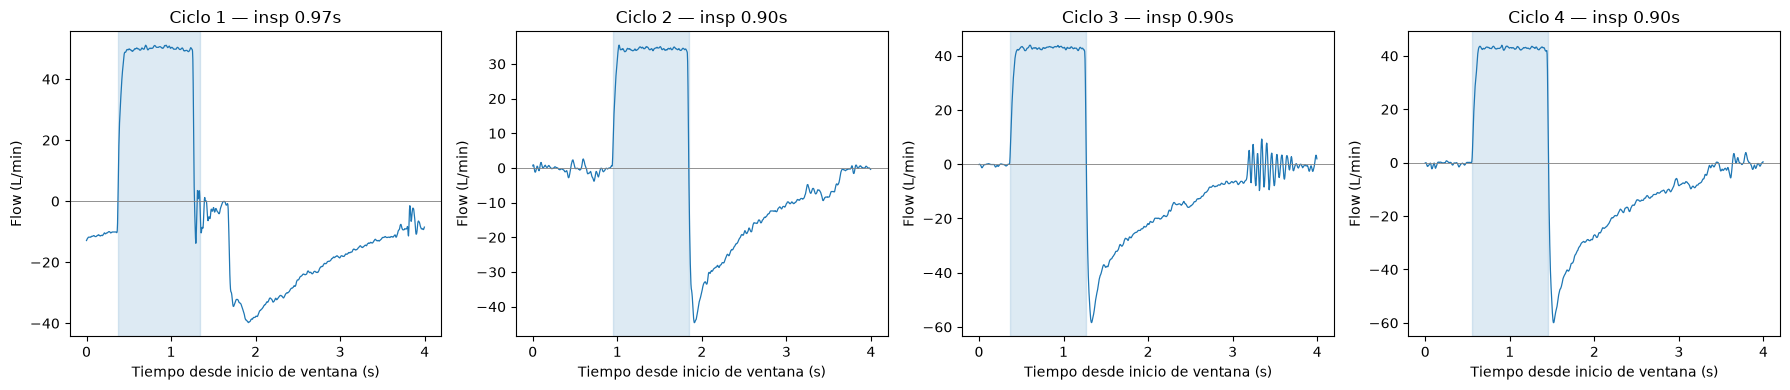

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for j, (nc, t0) in enumerate(ciclos_t.items()):
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)

    t = sub.Time.values - t0
    axes[j].plot(t, sub.Flow.values, color='tab:blue', lw=0.9)
    axes[j].axhline(0, color='gray', lw=0.6)
    if i_ini is not None:
        axes[j].axvspan(t[i_ini], t[i_fin - 1], color='tab:blue', alpha=0.15)
        dur = (i_fin - i_ini) / fs
        axes[j].set_title(f'Ciclo {nc} — insp {dur:.2f}s')
    else:
        axes[j].set_title(f'Ciclo {nc} — sin inspiración')
    axes[j].set_xlabel('Tiempo desde inicio de ventana (s)')
    axes[j].set_ylabel('Flow (L/min)')

plt.tight_layout()
plt.show()

In [30]:
def metricas_ciclo(t0, df, fs):
    sub = df[(df.Time >= t0) & (df.Time < t0 + 4)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)
    if i_ini is None:
        return None

    F   = sub.Flow.values[i_ini:i_fin] / 60.0   # L/s
    Paw = sub.Paw.values[i_ini:i_fin]
    Pes = sub.Pes.values[i_ini:i_fin]

    V = np.cumsum(F) / fs
    V = V - V[0]

    def r2_fit(y, cols):
        X = np.column_stack(cols + [np.ones_like(y)])
        beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        y_pred = X @ beta
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        resid_std = np.sqrt(ss_res / len(y))
        return r2, resid_std

    corr = np.corrcoef(Paw, Pes)[0, 1]
    r2_model, _ = r2_fit(Paw, [F, V])
    r2_pes, resid_pes = r2_fit(Pes, [V, F])

    return corr, r2_model, r2_pes, resid_pes


print(f"{'Ciclo':>6} {'corr(Pes,Paw)':>14} {'R² Paw':>9} {'R² Pes~V,F':>12} {'resid Pes (cmH₂O)':>18}")
for nc, t0 in ciclos_t.items():
    m = metricas_ciclo(t0, df, fs)
    if m is None:
        print(f"{nc:>6} {'sin inspiración válida':>40}")
        continue
    corr, r2_model, r2_pes, resid_pes = m
    print(f"{nc:>6} {corr:>14.3f} {r2_model:>9.3f} {r2_pes:>12.3f} {resid_pes:>18.3f}")

 Ciclo  corr(Pes,Paw)    R² Paw   R² Pes~V,F  resid Pes (cmH₂O)
     1          0.225     0.935        0.137              0.466
     2          0.339     0.966        0.174              0.608
     3          0.739     0.981        0.762              0.567
     4          0.556     0.983        0.472              0.729


In [31]:
# --- Detección de TODAS las inspiraciones del registro D por cruces de flujo ---
F_all = df.Flow.values
n_all = len(F_all)
umbral_in = 2.0
persist = int(0.1 * fs)

# Marcar dónde el flujo está por encima del umbral (inspiración activa)
arriba = F_all >= umbral_in

# Flancos de subida: pasa de False a True
flancos = np.where(np.diff(arriba.astype(int)) == 1)[0] + 1

# Quedarse con los flancos que inician un tramo SOSTENIDO (evita ruido)
inicios = []
for idx in flancos:
    if idx + persist <= n_all and arriba[idx:idx+persist].all():
        # evitar duplicados muy cercanos (mismo ciclo)
        if not inicios or (idx - inicios[-1]) > int(1.0 * fs):
            inicios.append(idx)

print(f"Inspiraciones detectadas en el registro: {len(inicios)}")

# --- Volumen inspiratorio de cada inspiración detectada ---
def volumen_inspiratorio(i_start):
    """Integra el flujo desde el inicio hasta el fin de esa inspiración."""
    sub = df.iloc[i_start : i_start + int(4*fs)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)
    if i_ini is None:
        return None
    Fi = sub.Flow.values[i_ini:i_fin] / 60.0   # L/s
    Vi = np.sum(Fi) / fs                        # L (volumen que entró en la inspiración)
    return Vi * 1000                            # mL

volumenes = []
for i_start in inicios:
    v = volumen_inspiratorio(i_start)
    if v is not None:
        volumenes.append(v)

volumenes = np.array(volumenes)
v_mediana = np.median(volumenes)

print(f"Volumen inspiratorio mediano del paciente: {v_mediana:.0f} mL")
print(f"Rango de volúmenes: {volumenes.min():.0f} – {volumenes.max():.0f} mL")

# --- Filtro de validez relativo al paciente ---
frac = 0.30
umbral_vol = frac * v_mediana
validas = volumenes >= umbral_vol

print(f"\nUmbral de validez: {umbral_vol:.0f} mL ({frac:.0%} de la mediana)")
print(f"Inspiraciones válidas: {validas.sum()} de {len(volumenes)}")
print(f"Descartadas por bajo volumen: {(~validas).sum()}")

Inspiraciones detectadas en el registro: 433
Volumen inspiratorio mediano del paciente: 668 mL
Rango de volúmenes: 8 – 1080 mL

Umbral de validez: 200 mL (30% de la mediana)
Inspiraciones válidas: 408 de 433
Descartadas por bajo volumen: 25


Correlaciones calculadas sobre 408 respiraciones válidas


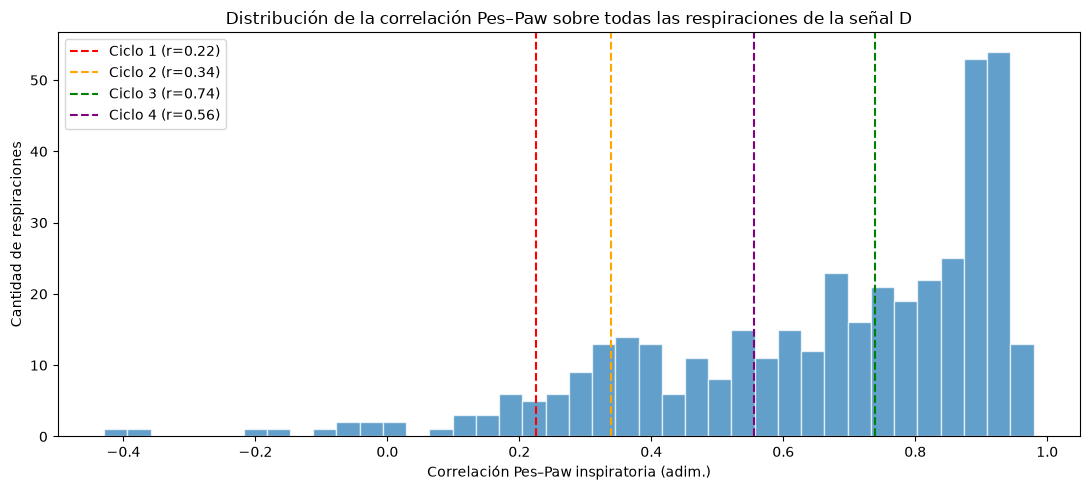

In [32]:
# --- Correlación Pes-Paw inspiratoria para cada inspiración válida ---
def corr_inspiratoria(i_start):
    sub = df.iloc[i_start : i_start + int(4*fs)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)
    if i_ini is None:
        return None
    Paw = sub.Paw.values[i_ini:i_fin]
    Pes = sub.Pes.values[i_ini:i_fin]
    if len(Paw) < 10 or Paw.std() == 0 or Pes.std() == 0:
        return None
    return np.corrcoef(Paw, Pes)[0, 1]

# Calcular sobre las inspiraciones válidas (volumen >= umbral)
correlaciones = []
tiempos = []
for i_start, v in zip(inicios, volumenes):
    if v < umbral_vol:
        continue
    r = corr_inspiratoria(i_start)
    if r is not None and not np.isnan(r):
        correlaciones.append(r)
        tiempos.append(df.Time.values[i_start])

correlaciones = np.array(correlaciones)
tiempos = np.array(tiempos)
print(f"Correlaciones calculadas sobre {len(correlaciones)} respiraciones válidas")

# --- Histograma ---
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(correlaciones, bins=40, color='tab:blue', alpha=0.7, edgecolor='white')
ax.set_xlabel('Correlación Pes–Paw inspiratoria (adim.)')
ax.set_ylabel('Cantidad de respiraciones')
ax.set_title('Distribución de la correlación Pes–Paw sobre todas las respiraciones de la señal D')

# Marcar dónde caen los 4 ciclos conocidos
colores = {1: 'red', 2: 'orange', 3: 'green', 4: 'purple'}
for nc, t0 in ciclos_t.items():
    idx = np.argmin(np.abs(tiempos - t0))
    r_ciclo = correlaciones[idx]
    ax.axvline(r_ciclo, color=colores[nc], lw=1.5, linestyle='--',
               label=f'Ciclo {nc} (r={r_ciclo:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# --- Estimación de R, C, PEEP sobre las respiraciones que superan el criterio de pasividad ---
umbral_corr = 0.7

def estimar_RCP(i_start):
    """Ajusta el modelo de 2 elementos sobre una inspiración y devuelve R, C, PEEP, R²."""
    sub = df.iloc[i_start : i_start + int(4*fs)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)
    if i_ini is None:
        return None
    F   = sub.Flow.values[i_ini:i_fin] / 60.0   # L/s
    Paw = sub.Paw.values[i_ini:i_fin]
    V   = np.cumsum(F) / fs
    V   = V - V[0]
    X = np.column_stack([F, V, np.ones_like(F)])
    beta, _, _, _ = np.linalg.lstsq(X, Paw, rcond=None)
    R, E, PEEP = beta
    if E <= 0:
        return None                              # descarta ajustes sin sentido físico
    C = 1 / E
    Paw_pred = X @ beta
    r2 = 1 - np.sum((Paw - Paw_pred)**2) / np.sum((Paw - Paw.mean())**2)
    return R, C*1000, PEEP, r2                   # C en mL/cmH2O

# Recorrer las respiraciones válidas y quedarse con las que pasan el criterio de correlación
Rs, Cs, PEEPs = [], [], []
n_total = len(correlaciones)
n_pasan = 0

for i_start, v in zip(inicios, volumenes):
    if v < umbral_vol:
        continue
    r = corr_inspiratoria(i_start)
    if r is None or np.isnan(r) or r < umbral_corr:
        continue
    est = estimar_RCP(i_start)
    if est is None:
        continue
    R, C, PEEP, r2 = est
    Rs.append(R); Cs.append(C); PEEPs.append(PEEP)
    n_pasan += 1

Rs, Cs, PEEPs = np.array(Rs), np.array(Cs), np.array(PEEPs)

# --- Reporte de utilidad de la señal y precisión de la estimación ---
print(f"=== Análisis de utilidad de la señal ===")
print(f"Respiraciones válidas (volumen OK):      {n_total}")
print(f"Respiraciones pasivas (corr >= {umbral_corr}):    {n_pasan}  ({100*n_pasan/n_total:.1f}%)")
print()

def reporte(nombre, x, unidad):
    media = x.mean()
    sd = x.std(ddof=1)
    sem = sd / np.sqrt(len(x))
    print(f"{nombre:>6}: {media:7.2f} ± {sem:5.2f} {unidad}   "
          f"(SD={sd:.2f}, error rel.={100*sem/media:.1f}%)")

print("Estimación (promedio ± SEM):")
reporte("R", Rs, "cmH₂O/(L/s)")
reporte("C", Cs, "mL/cmH₂O")
reporte("PEEP", PEEPs, "cmH₂O")

=== Análisis de utilidad de la señal ===
Respiraciones válidas (volumen OK):      408
Respiraciones pasivas (corr >= 0.7):    221  (54.2%)

Estimación (promedio ± SEM):
     R:   12.45 ±  0.19 cmH₂O/(L/s)   (SD=2.78, error rel.=1.5%)
     C:   54.26 ±  1.46 mL/cmH₂O   (SD=21.75, error rel.=2.7%)
  PEEP:    7.88 ±  0.10 cmH₂O   (SD=1.46, error rel.=1.2%)


In [34]:
# --- Barrido de umbral de correlación: cómo cambian N, R, C, PEEP y su dispersión ---
umbrales = [0.7, 0.75, 0.8, 0.85, 0.9]

# Pre-calcular correlación y estimación de cada respiración válida UNA sola vez
datos = []  # (corr, R, C, PEEP)
for i_start, v in zip(inicios, volumenes):
    if v < umbral_vol:
        continue
    r = corr_inspiratoria(i_start)
    if r is None or np.isnan(r):
        continue
    est = estimar_RCP(i_start)
    if est is None:
        continue
    R, C, PEEP, r2 = est
    datos.append((r, R, C, PEEP))

datos = np.array(datos)  # columnas: corr, R, C, PEEP

print(f"{'umbral':>7} {'N':>5} {'% pas':>6} "
      f"{'R media':>8} {'R SD':>6} "
      f"{'C media':>8} {'C SD':>6} "
      f"{'PEEP':>6}")
for u in umbrales:
    mask = datos[:, 0] >= u
    sub = datos[mask]
    N = len(sub)
    pct = 100 * N / len(datos)
    R_m, R_sd = sub[:,1].mean(), sub[:,1].std(ddof=1)
    C_m, C_sd = sub[:,2].mean(), sub[:,2].std(ddof=1)
    P_m = sub[:,3].mean()
    print(f"{u:>7.2f} {N:>5} {pct:>5.1f}% "
          f"{R_m:>8.2f} {R_sd:>6.2f} "
          f"{C_m:>8.2f} {C_sd:>6.2f} "
          f"{P_m:>6.2f}")

 umbral     N  % pas  R media   R SD  C media   C SD   PEEP
   0.70   221  54.2%    12.45   2.78    54.26  21.75   7.88
   0.75   197  48.3%    12.49   2.83    52.36   7.69   7.87
   0.80   167  40.9%    12.47   2.82    51.88   6.83   7.85
   0.85   136  33.3%    12.23   2.26    51.79   6.17   7.89
   0.90    89  21.8%    12.27   2.10    51.92   6.32   7.90


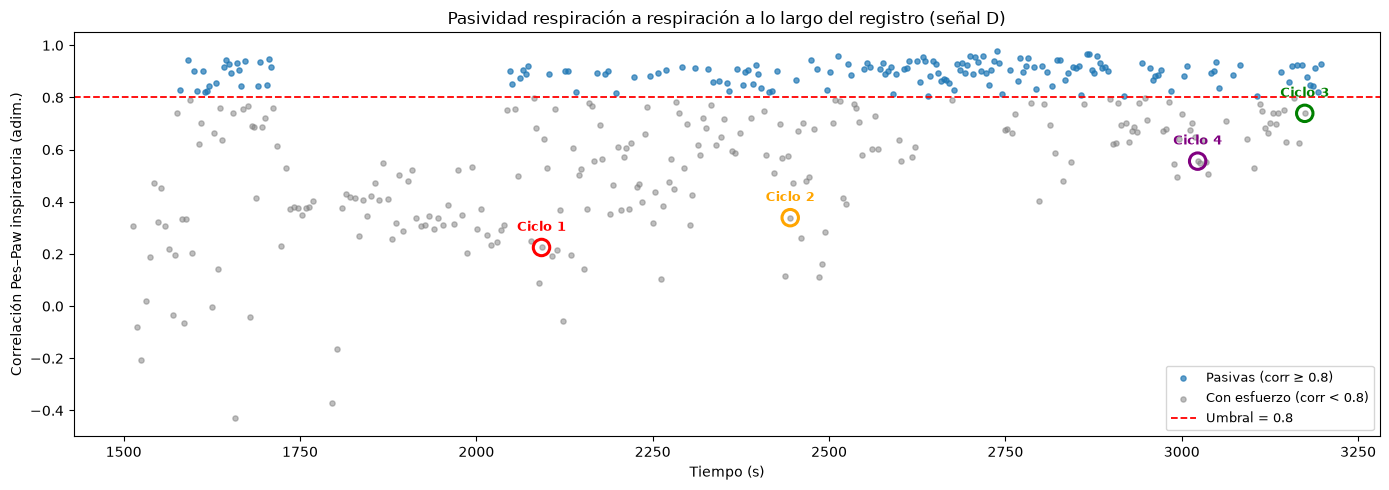

In [35]:
# --- Correlación vs tiempo de todas las respiraciones válidas, con umbral y ciclos originales ---
umbral_corr = 0.80

# Recalcular correlación + tiempo de cada respiración válida (por si acaso)
corr_t, corr_v = [], []
for i_start, v in zip(inicios, volumenes):
    if v < umbral_vol:
        continue
    r = corr_inspiratoria(i_start)
    if r is None or np.isnan(r):
        continue
    corr_t.append(df.Time.values[i_start])
    corr_v.append(r)
corr_t, corr_v = np.array(corr_t), np.array(corr_v)

# Clasificar según umbral
pasivas = corr_v >= umbral_corr

fig, ax = plt.subplots(figsize=(14, 5))

# Puntos: pasivas en azul, con esfuerzo en gris
ax.scatter(corr_t[pasivas],  corr_v[pasivas],  s=14, color='tab:blue',
           label=f'Pasivas (corr ≥ {umbral_corr})', alpha=0.7)
ax.scatter(corr_t[~pasivas], corr_v[~pasivas], s=14, color='tab:gray',
           label=f'Con esfuerzo (corr < {umbral_corr})', alpha=0.5)

# Línea de umbral
ax.axhline(umbral_corr, color='red', lw=1.3, linestyle='--', label=f'Umbral = {umbral_corr}')

# Marcar los 4 ciclos originales
colores = {1: 'red', 2: 'orange', 3: 'green', 4: 'purple'}
for nc, t0 in ciclos_t.items():
    idx = np.argmin(np.abs(corr_t - t0))
    ax.scatter(corr_t[idx], corr_v[idx], s=140, facecolors='none',
               edgecolors=colores[nc], linewidths=2.2, zorder=5)
    ax.annotate(f'Ciclo {nc}', (corr_t[idx], corr_v[idx]),
                textcoords='offset points', xytext=(0, 12),
                fontsize=9, color=colores[nc], ha='center', fontweight='bold')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Correlación Pes–Paw inspiratoria (adim.)')
ax.set_title('Pasividad respiración a respiración a lo largo del registro (señal D)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

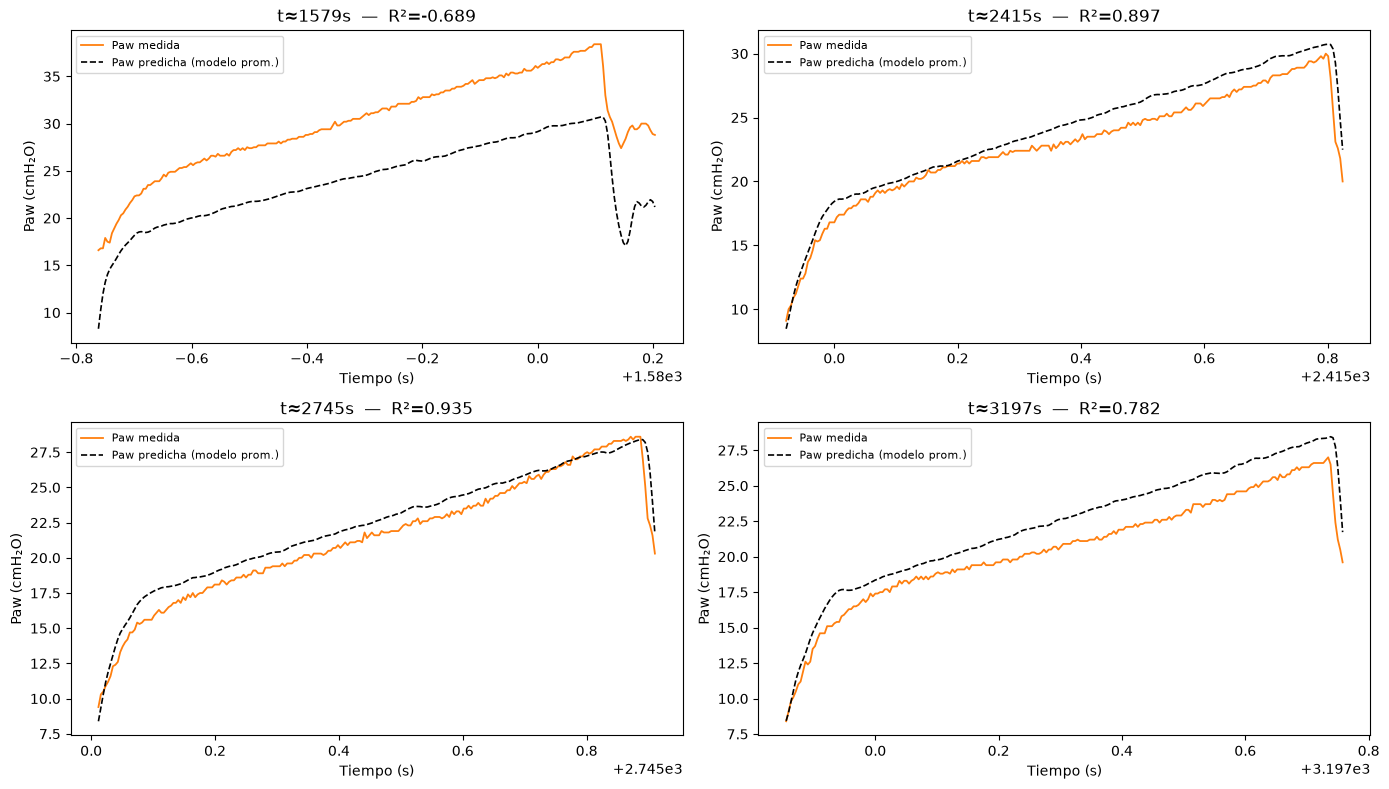

In [36]:
# --- Validación 1: Paw real vs Paw predicha por el modelo PROMEDIO, en respiraciones pasivas ---
# Parámetros promedio definitivos (umbral 0.80)
R_prom, C_prom, PEEP_prom = 12.47, 51.88, 7.85     # C en mL/cmH2O
E_prom = 1.0 / (C_prom / 1000.0)                     # elastancia en cmH2O/L

# Elegir algunas respiraciones pasivas representativas (bien espaciadas en el tiempo)
pasivas_idx = [i_start for i_start, v in zip(inicios, volumenes)
               if v >= umbral_vol
               and (corr_inspiratoria(i_start) or 0) >= 0.80]

# Tomar 4 repartidas a lo largo del registro
sel = [pasivas_idx[k] for k in np.linspace(0, len(pasivas_idx)-1, 4).astype(int)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, i_start in zip(axes.flat, sel):
    sub = df.iloc[i_start : i_start + int(4*fs)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)
    t   = sub.Time.values[i_ini:i_fin]
    F   = sub.Flow.values[i_ini:i_fin] / 60.0
    Paw = sub.Paw.values[i_ini:i_fin]
    V   = np.cumsum(F) / fs; V = V - V[0]

    # Paw predicha con los parámetros PROMEDIO
    Paw_pred = R_prom * F + E_prom * V + PEEP_prom
    r2 = 1 - np.sum((Paw - Paw_pred)**2) / np.sum((Paw - Paw.mean())**2)

    ax.plot(t, Paw,      color='tab:orange', lw=1.3, label='Paw medida')
    ax.plot(t, Paw_pred, color='black', lw=1.2, ls='--', label='Paw predicha (modelo prom.)')
    ax.set_title(f't≈{sub.Time.values[i_ini]:.0f}s  —  R²={r2:.3f}')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Paw (cmH₂O)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

R² ajuste INDIVIDUAL:  mediana=0.980  min=0.922  % con R²>0.9: 100%
R² modelo PROMEDIO:    mediana=0.796  min=-1.382  % con R²>0.9: 20%


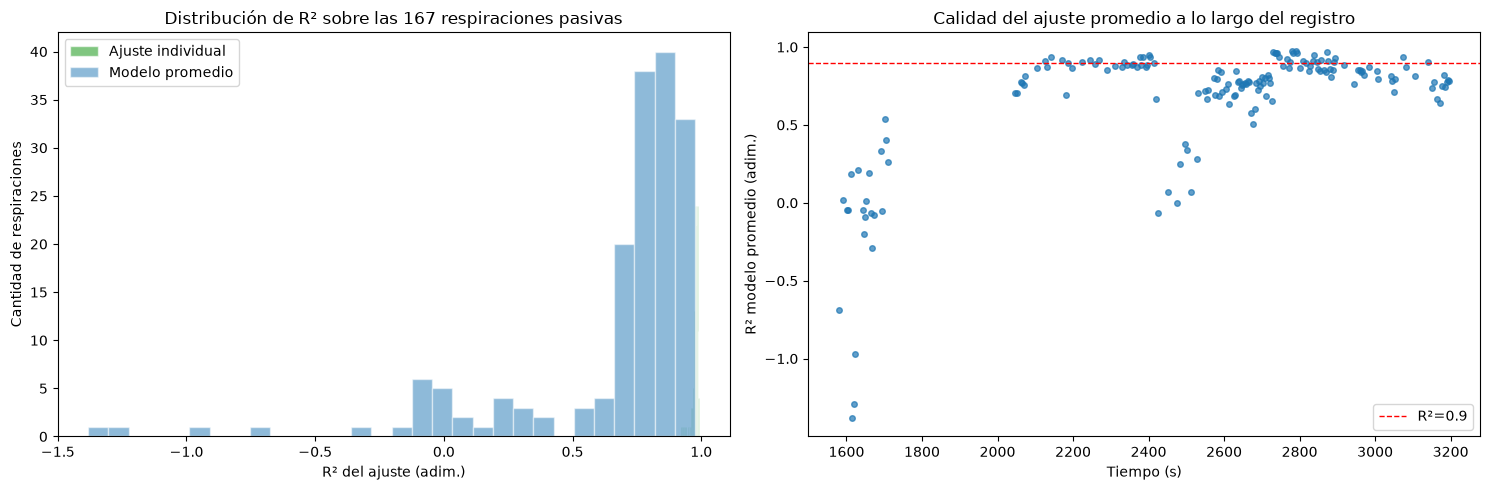

In [37]:
# --- Validación 2: distribución de R² sobre las 167 respiraciones pasivas ---
R_prom, C_prom, PEEP_prom = 12.47, 51.88, 7.85
E_prom = 1.0 / (C_prom / 1000.0)

r2_indiv, r2_promedio, tiempos_pas = [], [], []

for i_start, v in zip(inicios, volumenes):
    if v < umbral_vol:
        continue
    r = corr_inspiratoria(i_start)
    if r is None or np.isnan(r) or r < 0.80:
        continue

    sub = df.iloc[i_start : i_start + int(4*fs)].reset_index(drop=True)
    i_ini, i_fin = fase_inspiratoria(sub, fs=fs)
    F   = sub.Flow.values[i_ini:i_fin] / 60.0
    Paw = sub.Paw.values[i_ini:i_fin]
    V   = np.cumsum(F) / fs; V = V - V[0]

    # R² del ajuste INDIVIDUAL (parámetros óptimos de esta respiración)
    X = np.column_stack([F, V, np.ones_like(F)])
    beta, _, _, _ = np.linalg.lstsq(X, Paw, rcond=None)
    Paw_fit = X @ beta
    r2_i = 1 - np.sum((Paw - Paw_fit)**2) / np.sum((Paw - Paw.mean())**2)

    # R² del modelo PROMEDIO aplicado a esta respiración
    Paw_pred = R_prom * F + E_prom * V + PEEP_prom
    r2_p = 1 - np.sum((Paw - Paw_pred)**2) / np.sum((Paw - Paw.mean())**2)

    r2_indiv.append(r2_i)
    r2_promedio.append(r2_p)
    tiempos_pas.append(df.Time.values[i_start])

r2_indiv = np.array(r2_indiv)
r2_promedio = np.array(r2_promedio)
tiempos_pas = np.array(tiempos_pas)

# --- Estadísticas ---
print(f"R² ajuste INDIVIDUAL:  mediana={np.median(r2_indiv):.3f}  "
      f"min={r2_indiv.min():.3f}  "
      f"% con R²>0.9: {100*np.mean(r2_indiv>0.9):.0f}%")
print(f"R² modelo PROMEDIO:    mediana={np.median(r2_promedio):.3f}  "
      f"min={r2_promedio.min():.3f}  "
      f"% con R²>0.9: {100*np.mean(r2_promedio>0.9):.0f}%")

# --- Gráficos ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma comparativo
axes[0].hist(r2_indiv, bins=30, color='tab:green', alpha=0.6, label='Ajuste individual', edgecolor='white')
axes[0].hist(r2_promedio, bins=30, color='tab:blue', alpha=0.5, label='Modelo promedio', edgecolor='white')
axes[0].set_xlabel('R² del ajuste (adim.)')
axes[0].set_ylabel('Cantidad de respiraciones')
axes[0].set_title('Distribución de R² sobre las 167 respiraciones pasivas')
axes[0].legend()

# R² del modelo promedio vs tiempo (para ver si el mal ajuste está localizado)
axes[1].scatter(tiempos_pas, r2_promedio, s=16, color='tab:blue', alpha=0.7)
axes[1].axhline(0.9, color='red', lw=1, ls='--', label='R²=0.9')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('R² modelo promedio (adim.)')
axes[1].set_title('Calidad del ajuste promedio a lo largo del registro')
axes[1].legend()

plt.tight_layout()
plt.show()